# GDELT Crisis Media Coverage vs. CERF Funding

This notebook measures **crisis media attention** from the GDELT Event Database and plots it against CERF Underfunded Emergency (UFE) allocations (2022–2024).

### Goal
Test whether international media coverage of a humanitarian crisis — measured via the GDELT tone signal — correlates with the amount of emergency funding a country receives from CERF. "Quiet crises" are countries that receive proportionally more funding than their media coverage would suggest; "overcovered" crises are the opposite.

### Pipeline overview
| Step | What happens |
|------|--------------|
| §1 Download | Fetch GDELT daily event files for 4 sampled days/month (1st, 8th, 15th, 22nd) → ~144 files across 2022–2024. Filter and cache. |
| §2 CNI | Aggregate `AvgTone` of crisis events (GoldsteinScale ≤ −1) into **Crisis News Intensity** per country × half-year round. Normalise 0–100 (higher = more alarming). |
| §3 CERF | Load the unified CERF dataset; aggregate total funding and project count to country level. |
| §4 Country CNI | Roll up the per-round CNI to a single country-level score. |
| §5 Merge | Inner-join CERF and GDELT on ISO3 country code. |
| §6 Outliers | Rank countries by USD-per-crisis-article to surface under/over-reported crises. |
| §7 Correlation | Build a per-round panel; test lagged CNI against CIRV and log-CERF with a scatter matrix + heatmap. |

### Key design choices
1. **Sampling**: 4 days/month is a ~13 % sample of GDELT volume. This trades completeness for speed; article volumes are not directly comparable to daily totals.
2. **CNI metric** — mean `AvgTone` of all events with `GoldsteinScale ≤ −1` per country-round. More negative tone = more alarming crisis coverage. Normalised so that higher → worse.
3. **Country matching** — CERF uses ISO 3166-1 alpha-3; GDELT uses FIPS 10-4. A manual mapping covers all CERF-funded countries.
4. **Lag** — CNI is blended 50/50 with the previous half-year to proxy a ~3-month lag between media peaks and funding decisions.

> **⚠ Known limitation**: The CERF dataset (§3) contains *both* UFE and Rapid Response (RR) allocations. The correlation panel in §7 sums **all** CERF windows per country-round, not UFE-only. Labels referencing 'UFE' in older outputs are stale; treat the funding variable as total CERF.


## Setup

In [11]:
import datetime
import io
import zipfile
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# ── Paths ────────────────────────────────────────────────────────────────────
CACHE_DIR  = Path('../data/cache')   # one CSV per GDELT day
CNI_PATH   = Path('../data/gdelt_coverage.csv')  # aggregated CNI output
CERF_PATH  = Path('../initial_data/unified_cerf_2022_2024.csv') # merged CERF+CIRV dataset

# ── ISO3 (CERF) → FIPS 10-4 (GDELT ActionGeo_CountryCode) ───────────────────
# GDELT stores country codes in the US government FIPS 10-4 standard, not ISO 3166.
# This mapping was built manually for every country that appears in the CERF dataset.
# PSE (occupied Palestinian territory) maps to BOTH 'GZ' (Gaza) and 'WE' (West Bank)
# so both codes resolve to the same ISO3 in the inverse map.
ISO3_TO_FIPS = {
    # ── UFE countries ────────────────────────────────────────────────────────
    'AFG': 'AF', 'DZA': 'AG', 'AGO': 'AO', 'BGD': 'BG', 'BFA': 'UV',
    'BDI': 'BY', 'CMR': 'CM', 'CAF': 'CT', 'TCD': 'CD', 'COL': 'CO',
    'COD': 'CG', 'ERI': 'ER', 'ETH': 'ET', 'HTI': 'HA', 'HND': 'HO',
    'KEN': 'KE', 'LBN': 'LE', 'MDG': 'MA', 'MWI': 'MI', 'MLI': 'ML',
    'MOZ': 'MZ', 'MMR': 'BM', 'NER': 'NG', 'NGA': 'NI', 'PAK': 'PK',
    'SDN': 'SU', 'SSD': 'OD', 'SYR': 'SY', 'UGA': 'UG', 'VEN': 'VE',
    'YEM': 'YM', 'PSE': 'GZ',
    # ── Additional Rapid Response countries ──────────────────────────────────
    'SOM': 'SO', 'UKR': 'UP', 'MRT': 'MR', 'DJI': 'DJ', 'NPL': 'NP',
    'LKA': 'CE', 'GMB': 'GA', 'ZWE': 'ZI', 'CUB': 'CU', 'KGZ': 'KG',
    'TUR': 'TU', 'IRN': 'IR', 'VUT': 'NH', 'PER': 'PE', 'EGY': 'EG',
    'RWA': 'RW', 'PAN': 'PM', 'LBY': 'LY', 'ARM': 'AM', 'TLS': 'TT',
    'COG': 'CF', 'ZMB': 'ZA', 'MNG': 'MG', 'COM': 'CN', 'PHL': 'RP',
    'JAM': 'JM', 'GRD': 'GJ', 'NAM': 'WA', 'LSO': 'LT', 'VNM': 'VM',
    'GIN': 'GV',
}
# Reverse lookup: FIPS → ISO3
FIPS_TO_ISO3 = {v: k for k, v in ISO3_TO_FIPS.items()}
FIPS_TO_ISO3['WE'] = 'PSE'   # West Bank → same ISO3 as Gaza
TARGET_FIPS = set(ISO3_TO_FIPS.values()) | {'WE'}  # all FIPS codes we care about

# ── GDELT 1.0 column positions (0-indexed, tab-separated, no header) ─────────
# Full schema: http://data.gdeltproject.org/documentation/GDELT-Event_Codebook-V2.0.pdf
# We only need five columns to compute CNI; selecting them upfront saves memory.
GDELT_USECOLS   = [1, 30, 33, 34, 51]
GDELT_COL_NAMES = ['SQLDATE', 'GoldsteinScale', 'NumArticles', 'AvgTone', 'ActionGeo_CountryCode']
GDELT_URL = 'http://data.gdeltproject.org/events/{date}.export.CSV.zip'

# Goldstein scale: −10 (most destabilising) → +10 (most cooperative).
# We keep only events at or below −1 (any negative/destabilising event).
# The threshold is applied at aggregation time so changing it doesn't force a re-download.
GOLDSTEIN_THRESHOLD = -1

# ── Continent colour palette for scatter plots ────────────────────────────────
CONTINENT_COLOURS = {
    'Africa': '#E07B39', 'Asia': '#5B8DB8', 'Americas': '#6BAE75',
    'Europe': '#9B6BB5', 'Oceania': '#C4A84F',
}


## 1. Download & Cache GDELT Data

GDELT publishes one ~100 MB TSV file per day. We sample **4 representative days per month** (1st, 8th, 15th, 22nd), giving ~144 daily files across the 3-year window 2022–2024.

**Why a sample?**  
Downloading all ~1 095 daily files would take hours and ~100 GB of bandwidth. The 4-day sample captures ~13 % of events but is sufficient to measure relative intensity changes across countries and periods. Volume figures (`crisis_article_volume`) are therefore *relative*, not absolute totals.

**Caching strategy**  
Each parsed daily file is saved as a lightweight CSV in `gdelt_cache/`. Subsequent runs skip the download and read the cache directly, making re-runs instant.

> **Note on the cache boundary**: The cache stores **all** events with `GoldsteinScale < 0` (strictly negative), while the CNI metric in §2 then applies the configurable `GOLDSTEIN_THRESHOLD = −1`. This means you can tighten the threshold to e.g. −3 without re-downloading — the cache already contains all data you would need down to −10.


In [12]:
def sample_dates(start_year: int, end_year: int) -> list:
    """Return YYYYMMDD strings for the 1st, 8th, 15th and 22nd of every month.

    Dates in the future are excluded so the function is safe to call
    before the end of the current year.
    """
    today = datetime.date.today()
    dates = []
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            for day in (1, 8, 15, 22):
                try:
                    dt = datetime.date(year, month, day)
                    if dt <= today:
                        dates.append(dt.strftime('%Y%m%d'))
                except ValueError:
                    pass   # e.g. Feb 30 – just skip
    return dates


def download_and_parse(date_str: str) -> Optional[pd.DataFrame]:
    """Fetch one GDELT daily export, keep only crisis events in target countries.

    Steps:
    1. Return the cached CSV if it already exists.
    2. Download the ZIP from the GDELT server.
    3. Parse only the 5 columns we need (GDELT_USECOLS) to save memory.
    4. Filter rows to target FIPS country codes.
    5. Keep only events with GoldsteinScale < 0 (any crisis event).
       The stricter GOLDSTEIN_THRESHOLD is applied later at aggregation time
       so changing it never requires a re-download.
    6. Derive ISO3, date, year and half-year round (I/II) columns.
    7. Write the filtered DataFrame to the cache and return it.
    """
    cache_path = CACHE_DIR / f'{date_str}.csv'
    if cache_path.exists():
        return pd.read_csv(cache_path)

    url = GDELT_URL.format(date=date_str)
    try:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
    except requests.RequestException as exc:
        print(f'  [skip] {date_str}: {exc}')
        return None

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        with zf.open(zf.namelist()[0]) as fh:
            df = pd.read_csv(
                fh, sep='\t', header=None,
                usecols=GDELT_USECOLS, names=GDELT_COL_NAMES,
                dtype=str, on_bad_lines='skip',
            )

    # Keep only events that occurred in our target countries
    df = df[df['ActionGeo_CountryCode'].isin(TARGET_FIPS)].copy()

    df['GoldsteinScale'] = pd.to_numeric(df['GoldsteinScale'], errors='coerce')
    df['NumArticles']    = pd.to_numeric(df['NumArticles'], errors='coerce').fillna(0).astype(int)
    df['AvgTone']        = pd.to_numeric(df['AvgTone'], errors='coerce')

    # Cache all GoldsteinScale < 0 events (broader than GOLDSTEIN_THRESHOLD = −1).
    # This future-proofs the cache: you can re-aggregate with any threshold ≥ −10
    # without downloading again.
    crisis_df = df[df['GoldsteinScale'] < 0].copy()

    crisis_df['ISO3']        = crisis_df['ActionGeo_CountryCode'].map(FIPS_TO_ISO3)
    crisis_df['date_parsed'] = pd.to_datetime(crisis_df['SQLDATE'], format='%Y%m%d', errors='coerce')
    crisis_df['Year']        = crisis_df['date_parsed'].dt.year
    # Half-year 'Round': January–June → 'I', July–December → 'II'
    # This aligns with the CERF funding round convention.
    crisis_df['Round']       = crisis_df['date_parsed'].dt.month.apply(lambda m: 'I' if m <= 6 else 'II')

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    crisis_df.to_csv(cache_path, index=False)
    return crisis_df


In [13]:
dates = sample_dates(2022, 2024)
print(f'Fetching {len(dates)} daily GDELT files (weekly sampling, 2022-2024)...')

chunks = []
for i, date_str in enumerate(dates, 1):
    print(f'  [{i:3d}/{len(dates)}] {date_str}', end='  ')
    chunk = download_and_parse(date_str)
    if chunk is not None and not chunk.empty:
        chunks.append(chunk)
        print(f'→ {len(chunk):,} crisis rows')
    else:
        print('→ (no crisis rows)')

print(f'\nDownloaded {len(chunks)} files with data.')

Fetching 144 daily GDELT files (weekly sampling, 2022-2024)...
  [  1/144] 20220101  → 2,294 crisis rows
  [  2/144] 20220108  → 2,658 crisis rows
  [  3/144] 20220115  → 2,660 crisis rows
  [  4/144] 20220122  → 2,969 crisis rows
  [  5/144] 20220201  → 4,034 crisis rows
  [  6/144] 20220208  → 4,172 crisis rows
  [  7/144] 20220215  → 4,059 crisis rows
  [  8/144] 20220222  → 3,164 crisis rows
  [  9/144] 20220301  → 3,149 crisis rows
  [ 10/144] 20220308  → 3,841 crisis rows
  [ 11/144] 20220315  → 3,609 crisis rows
  [ 12/144] 20220322  → 3,896 crisis rows
  [ 13/144] 20220401  → 3,415 crisis rows
  [ 14/144] 20220408  → 3,572 crisis rows
  [ 15/144] 20220415  → 3,213 crisis rows
  [ 16/144] 20220422  → 3,903 crisis rows
  [ 17/144] 20220501  → 2,408 crisis rows
  [ 18/144] 20220508  → 2,548 crisis rows
  [ 19/144] 20220515  → 3,184 crisis rows
  [ 20/144] 20220522  → 2,760 crisis rows
  [ 21/144] 20220601  → 3,391 crisis rows
  [ 22/144] 20220608  → 3,304 crisis rows
  [ 23/144] 2

## 2. Compute Crisis News Intensity (CNI)

**Metric: mean `AvgTone`** of all events with `GoldsteinScale ≤ GOLDSTEIN_THRESHOLD` (−1), grouped by country × half-year round.

**Why `AvgTone`?**  
`AvgTone` captures the *emotional framing* of articles — famine stories, disease outbreaks, and displacement reporting all score deeply negative even when no violent act is coded (which is what GoldsteinScale primarily measures). The mean tone therefore reflects how alarming the overall media narrative around a country is.

**`AvgTone` vs `GoldsteinScale`**  
- `GoldsteinScale` (−10 to +10) measures the *geopolitical impact* of the event type (e.g. military attack = −10, peace negotiation = +10). We use it as a filter to keep only negative/crisis events.
- `AvgTone` (roughly −100 to +100) is the LIWC-derived *sentiment* of the actual text. It varies even within crisis events and is our primary intensity signal.

**Normalisation (0–100, higher = more alarming)**  
```
cni_normalized = (avg_tone − global_max) / (global_min − global_max) × 100
```
- When `avg_tone == global_min` (most negative/alarming): `cni_normalized = 100`
- When `avg_tone == global_max` (least negative): `cni_normalized = 0`

> **Note on `neg_event_count`**: In the aggregation below, `neg_event_count` is computed as `.count()` on the `NumArticles` column — this counts the **number of GDELT event rows**, not the sum of articles. `crisis_article_volume` is the sum of `NumArticles` per event row. Both are reference diagnostics; only `avg_tone` / `cni_normalized` is used analytically.


In [14]:
# ── Apply the Goldstein threshold (GOLDSTEIN_THRESHOLD = −1) ───────────────
# This is the first filter applied after loading from cache.
# The cache stores all GoldsteinScale < 0; here we narrow to ≤ −1.
combined = pd.concat(chunks, ignore_index=True)

cni = (
    combined[(combined['ISO3'].notna()) & (combined['GoldsteinScale'] <= GOLDSTEIN_THRESHOLD)]
    .groupby(['ISO3', 'Year', 'Round'], as_index=False)
    .agg(
        # Primary metric: mean sentiment tone of all crisis-event articles that round
        avg_tone=('AvgTone', 'mean'),
        # Sum of NumArticles across all crisis-event rows for that country-round
        # (a proxy for coverage volume; not comparable to full daily totals)
        crisis_article_volume=('NumArticles', 'sum'),
        # Number of individual GDELT event rows (not article count) — diagnostic only
        neg_event_count=('NumArticles', 'count'),
        # Mean Goldstein score of the filtered events — diagnostic only
        avg_goldstein=('GoldsteinScale', 'mean'),
    )
    .sort_values(['ISO3', 'Year', 'Round'])
)

# ── Normalise avg_tone → cni_normalized (0–100, higher = more alarming) ────
# Formula: (tone − global_max) / (global_min − global_max) × 100
# This inverts the scale so that the most-negative tone maps to 100.
# The denominator is always negative (min < max), so dividing a negative
# numerator by a negative denominator gives a positive result.
# Edge case: when tone == max, result is 0.0 (may print as −0.0 — harmless float artefact).
_min, _max = cni['avg_tone'].min(), cni['avg_tone'].max()
cni['cni_normalized'] = (cni['avg_tone'] - _max) / (_min - _max) * 100

CNI_PATH.parent.mkdir(parents=True, exist_ok=True)
cni.to_csv(CNI_PATH, index=False)
print(f'Saved {len(cni)} country-round CNI records → {CNI_PATH}')
print(f'avg_tone range: {cni["avg_tone"].min():.1f} to {cni["avg_tone"].max():.1f}')
print(f'cni_normalized range: {cni["cni_normalized"].min():.1f} to {cni["cni_normalized"].max():.1f}')
cni.head(10)


Saved 294 country-round CNI records → ../initial_data/gdelt_crisis_coverage.csv
avg_tone range: -15.4 to 5.3
cni_normalized range: -0.0 to 100.0


,ISO3,Year,Round,avg_tone,crisis_article_volume,neg_event_count,avg_goldstein,cni_normalized
0,AFG,2012,I,-3.539616,205,7,-6.428571,42.735288
1,AFG,2013,I,0.107469,4,1,-5.000000,25.143811
2,AFG,2014,I,-5.303613,6,1,-6.500000,51.243813
3,AFG,2021,I,-4.763311,2107,113,-6.280531,48.637701
4,AFG,2021,II,-5.354493,1491,92,-6.693478,51.489231
5,AFG,2022,I,-4.716399,82924,5596,-6.087062,48.411427
6,AFG,2022,II,-4.767583,77746,5348,-6.227431,48.658309
7,AFG,2023,I,-4.573370,97817,5360,-5.913937,47.721537
8,AFG,2023,II,-4.823530,74886,5478,-5.792716,48.928164
9,AFG,2024,I,-5.000494,41536,4060,-5.919581,49.781739


## 3. Load CERF Funding Data

Load `unified_cerf_2022_2024.csv` — a dataset that merges CERF project-level allocations (UFE and Rapid Response) with CIRV crisis severity scores at the country×round level.

The cell below aggregates across **all** CERF windows (UFE + RR) to produce one row per country with total funding and project count. A separate breakdown by window type is printed for reference.

> ⚠ **Important**: Because both UFE *and* RR rows exist in the CSV, the `cerf` DataFrame produced here contains combined totals. Any downstream analysis that needs UFE-only funding should filter `cerf_raw` on the window type column first.


In [15]:
cerf_raw = pd.read_csv(CERF_PATH)

# ── Diagnostic: how many rows per CERF window type? ─────────────────────────
# The CSV contains both UFE (Underfunded Emergency) and RR (Rapid Response) rows.
window_col = 'WindowType' if 'WindowType' in cerf_raw.columns else 'grantType'
if window_col in cerf_raw.columns:
    for wt, grp in cerf_raw.groupby(window_col):
        print(f'{wt} rows: {len(grp):,} | countries: {grp["ISO3_Standard"].nunique()}')
else:
    print(f'Total rows: {len(cerf_raw):,}')

# ── Aggregate over ALL funding windows to country level ─────────────────────
# total_cerf_usd = sum of all approved project amounts across all rounds and windows
# num_projects   = count of individual project rows (one row per project)
cerf = (
    cerf_raw
    .groupby(['ISO3_Standard', 'countryName', 'continentName'], as_index=False)
    .agg(
        total_cerf_usd=('totalAmountApproved', 'sum'),
        num_projects=('projectID', 'count'),
    )
    .rename(columns={'ISO3_Standard': 'ISO3'})
)

print(f'{len(cerf)} CERF countries | total funding: ${cerf["total_cerf_usd"].sum()/1e6:.1f} M')
cerf.sort_values('total_cerf_usd', ascending=False).head(10)


Total rows: 396
32 CERF countries | total funding: $745.2 M


,ISO3,countryName,continentName,total_cerf_usd,num_projects
27,SYR,Syrian Arab Republic,Asia,70626355.00,19
7,COD,Democratic Republic of the Congo,Africa,65729266.00,20
25,SDN,Republic of the Sudan,Africa,64243474.00,19
31,YEM,Yemen,Asia,60033654.48,21
18,MMR,Myanmar,Asia,44398154.68,32
11,ETH,Ethiopia,Africa,38999690.12,18
28,TCD,Chad,Africa,34399205.00,22
3,BFA,Burkina Faso,Africa,30763948.19,19
17,MLI,Mali,Africa,27750675.45,17
13,HTI,Haiti,Americas,26741644.97,19


## 4. Aggregate CNI to Country Level

Roll up the per-round CNI to a single representative score per country.

**How the country-level `cni_normalized` is computed**  
1. Mean `avg_tone` across all year-rounds for each country  
2. Re-normalise using the same inverted formula (higher = more alarming)  

> ⚠ **Implementation note**: The `groupby().agg()` below first computes a *summed* `cni_normalized` and a *summed* `crisis_article_volume`. The summed `cni_normalized` is immediately **overwritten** by the proper re-normalised score in the next block. Only `crisis_article_volume` (summed article count) and `neg_event_count` (summed event count) from the agg are kept. This is intentional but can look confusing — the intermediate summed `cni_normalized` is a throwaway.


In [16]:
# Aggregate to country level
# Note: cni_normalized column in this agg is the SUM of per-round normalised scores.
# It is immediately replaced below — the sum is just a placeholder for now.
cni_country = (
    cni
    .groupby('ISO3', as_index=False)
    .agg(
        crisis_article_volume=('crisis_article_volume', 'sum'),  # total sampled article volume
        _cni_normalized_sum=('cni_normalized', 'sum'),           # unused; overwritten below
        neg_event_count=('neg_event_count', 'sum'),              # total GDELT event rows
        avg_tone=('avg_tone', 'mean'),                           # mean tone across rounds
    )
    .drop(columns=['_cni_normalized_sum'])                       # discard the sum column
)

# Re-normalise using the mean tone across all rounds for each country.
# avg_tone already equals cni.groupby('ISO3')['avg_tone'].mean() — no need for a separate map.
_min, _max = cni_country['avg_tone'].min(), cni_country['avg_tone'].max()
cni_country['cni_normalized'] = (cni_country['avg_tone'] - _max) / (_min - _max) * 100

print(f'{len(cni_country)} countries with GDELT crisis coverage data')
cni_country.sort_values('cni_normalized', ascending=False).head(10)


32 countries with GDELT crisis coverage data


,ISO3,crisis_article_volume,neg_event_count,avg_tone,cni_normalized
17,MLI,55509,4868,-6.632193,100.000000
3,BFA,38933,3141,-6.265625,90.380339
24,PSE,321747,38859,-6.214505,89.038813
25,SDN,279857,18082,-6.131613,86.863517
23,PAK,827840,90281,-5.690737,75.293823
28,TCD,40971,3733,-5.575838,72.278588
5,CAF,10339,1075,-5.530475,71.088149
31,YEM,114965,9764,-5.489698,70.018059
19,MOZ,21052,2424,-5.488421,69.984539
12,HND,44981,2611,-5.397096,67.587939


## 5. Merge CERF × GDELT

Inner-join CERF country totals onto GDELT country-level CNI by ISO3 code.

An **inner join** drops any country that appears in only one dataset:
- Countries with CERF funding but no GDELT coverage (e.g. very small/isolated crises) are excluded.
- Countries with GDELT coverage but no CERF funding are excluded.

The number of matched countries should equal `min(len(cerf), len(cni_country))` when all CERF countries have GDELT entries — which is expected since we built the FIPS mapping specifically for CERF countries.


In [17]:
merged = cerf.merge(cni_country, on='ISO3', how='inner')
print(f'Matched {len(merged)} countries (of {len(cerf)} CERF, {len(cni_country)} GDELT)')
merged[['countryName', 'total_cerf_usd', 'crisis_article_volume', 'num_projects']].sort_values(
    'total_cerf_usd', ascending=False
).head(15)

Matched 32 countries (of 32 CERF, 32 GDELT)


,countryName,total_cerf_usd,crisis_article_volume,num_projects
27,Syrian Arab Republic,70626355.00,329338,19
7,Democratic Republic of the Congo,65729266.00,17529,20
25,Republic of the Sudan,64243474.00,279857,19
31,Yemen,60033654.48,114965,21
18,Myanmar,44398154.68,93231,32
11,Ethiopia,38999690.12,75945,18
28,Chad,34399205.00,40971,22
3,Burkina Faso,30763948.19,38933,19
17,Mali,27750675.45,55509,17
13,Haiti,26741644.97,106383,19


## 6. Outlier Analysis

Rank countries by **CERF USD per sampled crisis article** to identify:

| Category | Definition |
|----------|------------|
| **Under-reported** (quiet crises) | High total funding, low media volume → they receive money despite limited global attention |
| **Over-covered** (media-heavy, less supported) | High media volume, low funding → global attention does not translate into proportional CERF support |

> ⚠ **Sampling caveat**: `crisis_article_volume` counts `NumArticles` across only the 4 sampled days/month. Large countries (Nigeria, Pakistan) generate far more GDELT events simply because more things happen there — the metric partly reflects country size, not only crisis severity. Interpret outlier positions with this in mind.


In [18]:
merged['usd_per_crisis_article'] = merged['total_cerf_usd'] / merged['crisis_article_volume']

cols = ['countryName', 'total_cerf_usd', 'crisis_article_volume', 'usd_per_crisis_article']

print('Top 5 — most funded relative to media coverage (under-reported crises):')
display(merged.nlargest(5, 'usd_per_crisis_article')[cols].reset_index(drop=True))

print('\nTop 5 — least funded relative to media coverage (media-heavy, less supported):')
display(merged.nsmallest(5, 'usd_per_crisis_article')[cols].reset_index(drop=True))

Top 5 — most funded relative to media coverage (under-reported crises):


,countryName,total_cerf_usd,crisis_article_volume,usd_per_crisis_article
0,Democratic Republic of the Congo,65729266.00,17529,3749.744195
1,Madagascar,15559546.00,5050,3081.098218
2,Cameroon,20839972.60,19287,1080.519137
3,Mozambique,19949998.46,21052,947.653356
4,Burundi,5992935.38,6778,884.174591



Top 5 — least funded relative to media coverage (media-heavy, less supported):


,countryName,total_cerf_usd,crisis_article_volume,usd_per_crisis_article
0,Pakistan,6484314.0,827840,7.832811
1,Nigeria,10000000.0,843753,11.851810
2,occupied Palestinian territory,6700000.0,321747,20.823815
3,Afghanistan,20612124.0,413544,49.842638
4,Kenya,14001347.0,214367,65.314843


## 7. Per-Round Correlation: CNI × CIRV (Adjusted) × CERF Funding

Each observation is one **country-round** (e.g. Yemen 2022-I).
The three variables are:
- **CNI** — Crisis News Intensity: mean AvgTone of destabilising events that round (0–100, higher = more alarming)
- **CIRV (Adjusted)** — crisis vulnerability score for that country-round (from the CERF dataset)
- **CERF (M USD)** — total funding approved that round across all CERF windows (UFE + RR)

> ⚠ **Scope note**: The panel in §7 uses `cerf_raw` unfiltered (UFE + RR rows combined). Older cell output labels say 'CERF UFE' but the code sums all windows. This gives a fuller picture of total funding but conflates the two mechanisms.

A **scatter matrix** shows pairwise relationships; the **heatmap** gives Pearson r coefficients.
CERF is log-transformed (right-skewed distribution); CNI is already on a 0–100 scale; CIRV is on a linear scale.

**Lagged CNI**  
A ~3-month lag is approximated by a 50/50 blend of the current and previous half-year CNI. This accounts for the typical delay between media coverage spikes and funding allocation.


### Data assembly (`corr-merge`)

Builds the per-round panel with three variables aligned on ISO3 × Year × Round:

1. **CIRV** — deduplicates `cerf_raw` to one row per country-round (taking the first CIRV (Adjusted) value; duplicates arise because multiple projects share the same country-round CIRV score)
2. **CERF funding** — sums `totalAmountApproved` across ALL projects for that country-round (both UFE and RR rows)
3. **CNI** — left-joined from the §2 per-round table; drops rows with no GDELT coverage

**Lagged CNI construction**  
- Periods are ordered chronologically: 2022-I → 0, 2022-II → 1, 2023-I → 2, …
- `cni_prev` shifts each country's CNI forward by one period (simulates looking at the previous round's CNI while in the current round)
- `cni_lagged = 0.5 × cni_current + 0.5 × cni_prev` for rows where prev exists; otherwise `cni_lagged = cni_current` (first round has no predecessor)

> ⚠ **Period index note**: `period_order` only covers 2022–2024 rounds. Any rows in `cerf_raw` with Year outside this range receive `period_idx = −1`, meaning they are treated as 'first round' (no lag). This is correct for the data at hand but would silently produce wrong lag values if earlier years were added.


In [19]:
# ── 1. CIRV per country-round ────────────────────────────────────────────────
# cerf_raw has multiple project rows per country-round, all sharing the same CIRV score.
# drop_duplicates keeps exactly one representative row per (ISO3, Year, Round).
cirv_rounds = (
    cerf_raw
    .drop_duplicates(subset=['ISO3_Standard', 'Year', 'Round'])
    [['ISO3_Standard', 'Year', 'Round', 'CIRV (Adjusted)', 'countryName']]
    .rename(columns={'ISO3_Standard': 'ISO3', 'CIRV (Adjusted)': 'cirv_adjusted'})
)

# ── 2. CERF funding per country-round ────────────────────────────────────────
# Sums ALL project amounts for a given country-round across BOTH UFE and RR windows.
# To restrict to UFE only you would add: cerf_raw[cerf_raw['grantType'] == 'UFE']
cerf_rounds_agg = (
    cerf_raw
    .groupby(['ISO3_Standard', 'Year', 'Round'], as_index=False)
    .agg(cerf_usd=('totalAmountApproved', 'sum'))
    .rename(columns={'ISO3_Standard': 'ISO3'})
)

# ── 3. Three-way merge on ISO3 × Year × Round ────────────────────────────────
# Start with CIRV (inner-merge with CERF funding so rows without any funding are dropped)
# then left-join CNI (rows without GDELT data are kept but then dropped by dropna).
panel = (
    cirv_rounds
    .merge(cerf_rounds_agg, on=['ISO3', 'Year', 'Round'], how='inner')
    .merge(cni[['ISO3', 'Year', 'Round', 'cni_normalized']], on=['ISO3', 'Year', 'Round'], how='left')
    .dropna(subset=['cirv_adjusted', 'cerf_usd', 'cni_normalized'])
)
panel['period']   = panel['Year'].astype(str) + '-' + panel['Round']
panel['cerf_usd_m'] = np.log10(panel['cerf_usd'].clip(lower=1))  # log10 to compress right-skew
print(f'Panel: {len(panel)} country-round observations across {panel["ISO3"].nunique()} countries')
panel[['countryName','period','cni_normalized','cirv_adjusted','cerf_usd']].sort_values('cerf_usd', ascending=False).head(10)

# ── ~3-month lagged CNI (50/50 blend current + previous round) ───────────────
# Map each (Year, Round) pair to a sequential integer so we can find 'previous round'
# by subtracting 1 from the index.
period_order = {(y, r): i for i, (y, r) in enumerate(
    [(y, r) for y in [2022, 2023, 2024] for r in ['I', 'II']]
)}
# period_order covers 2022–2024 only; rows outside this range get index −1
# and are treated as 'no previous period' (lag falls back to current CNI).

cni_indexed = cni[["ISO3", "Year", "Round", "cni_normalized"]].copy()
cni_indexed['period_idx'] = cni_indexed.apply(
    lambda row: period_order.get((row['Year'], row['Round']), -1), axis=1
)

# Build a lookup table: for each (ISO3, period_idx) return the CNI of the *previous* period.
# We do this by shifting period_idx +1: a row at index 1 becomes a lookup for index 2,
# meaning 'this is what period 2 should use as its lagged value'.
cni_prev = cni_indexed[["ISO3", "period_idx", "cni_normalized"]].copy()
cni_prev['period_idx'] = cni_prev['period_idx'] + 1
cni_prev = cni_prev.rename(columns={'cni_normalized': 'cni_prev'})

panel['period_idx'] = panel.apply(
    lambda row: period_order.get((row['Year'], row['Round']), -1), axis=1
)
panel_lagged = panel.merge(cni_prev, on=["ISO3", "period_idx"], how="left")

# Blend: 50 % current + 50 % previous round (when previous exists)
panel_lagged['cni_lagged'] = np.where(
    panel_lagged['cni_prev'].notna(),
    0.5 * panel_lagged['cni_normalized'] + 0.5 * panel_lagged['cni_prev'],
    panel_lagged['cni_normalized'],   # fallback: first round has no predecessor
)
panel_lagged = panel_lagged.drop(columns=['cni_prev'])

n_blended      = (panel_lagged['period_idx'] > 0).sum()
n_current_only = len(panel_lagged) - n_blended
print(f'{len(panel_lagged)} observations | {n_blended} blended with lag, {n_current_only} current-round only')
panel_lagged[['countryName', 'period', 'cni_lagged', 'cni_normalized', 'cerf_usd']].head(8)


Panel: 74 country-round observations across 32 countries
102 observations | 61 blended with lag, 41 current-round only


,countryName,period,cni_lagged,cni_normalized,cerf_usd
0,Niger,2022-I,43.866805,55.335107,9998659.0
1,Niger,2022-I,58.483006,55.335107,9998659.0
2,Niger,2022-I,54.912521,55.335107,9998659.0
3,Chad,2022-I,53.919719,53.285266,9999375.0
4,Chad,2022-I,52.478642,53.285266,9999375.0
5,Lebanon,2022-I,44.462867,46.480182,8002513.0
6,Lebanon,2022-I,39.583101,46.480182,8002513.0
7,Lebanon,2022-I,50.920137,46.480182,8002513.0


Saved → ../reports/gdelt_cerf_correlation.png

CNI lagged → CERF : r = +0.058
CIRV       → CERF : r = +0.368


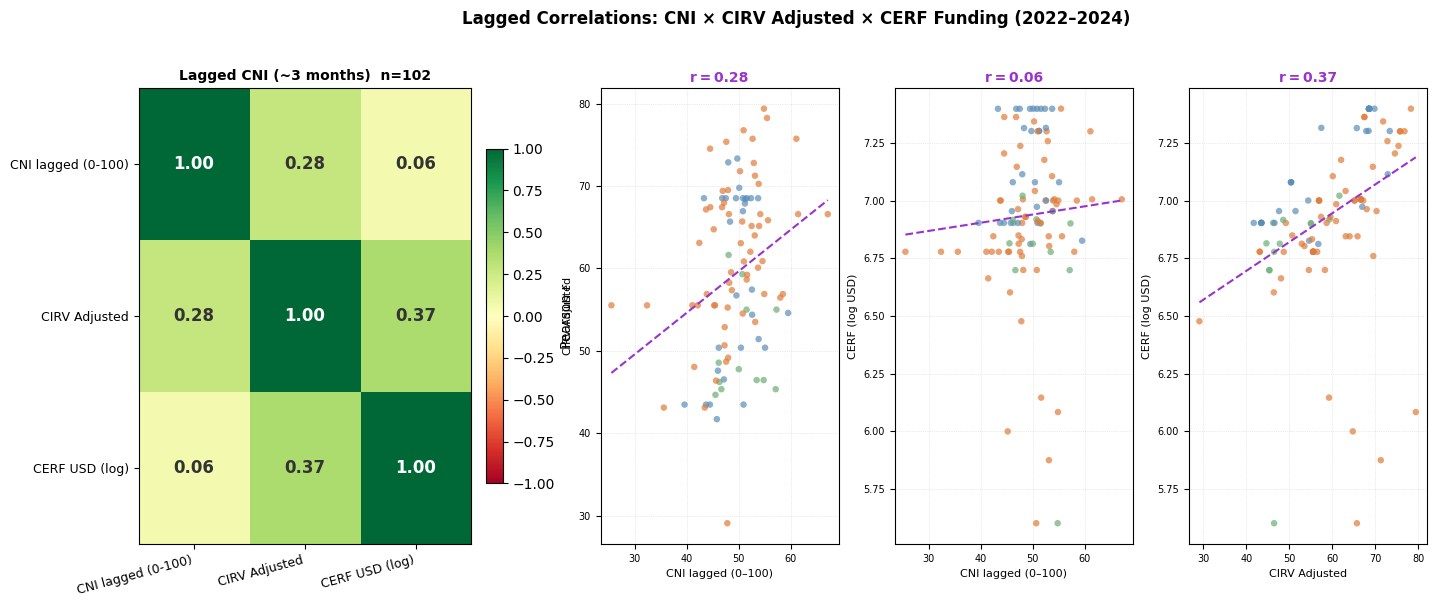

In [20]:
# Include CIRV in the lagged panel for heatmap
corr_lagged = panel_lagged[['cni_lagged', 'cirv_adjusted', 'cerf_usd_m']].rename(columns={
    'cni_lagged':    'CNI lagged (0-100)',
    'cirv_adjusted': 'CIRV Adjusted',
    'cerf_usd_m':      'CERF USD (M)',
}).corr()

cont_map = cerf_raw.drop_duplicates('ISO3_Standard').set_index('ISO3_Standard')['continentName'].to_dict()
dot_cl = panel_lagged['ISO3'].map(cont_map).map(lambda c: CONTINENT_COLOURS.get(c, '#888888'))

fig = plt.figure(figsize=(14, 6))

# ── Correlation heatmap ──────────────────────────────────────────────────────
ax_h = fig.add_axes([0.03, 0.12, 0.26, 0.76])
im = ax_h.imshow(corr_lagged.values, vmin=-1, vmax=1, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax_h, fraction=0.046, pad=0.04, label='Pearson r')
labs = corr_lagged.columns.tolist()
ax_h.set_xticks(range(len(labs))); ax_h.set_xticklabels(labs, rotation=15, ha='right', fontsize=9)
ax_h.set_yticks(range(len(labs))); ax_h.set_yticklabels(labs, fontsize=9)
for i in range(len(labs)):
    for j in range(len(labs)):
        ax_h.text(j, i, f'{corr_lagged.values[i,j]:.2f}', ha='center', va='center',
                  fontsize=12, fontweight='bold',
                  color='white' if abs(corr_lagged.values[i,j]) > 0.55 else '#333333')
ax_h.set_title(f'Lagged CNI (~3 months)  n={len(panel_lagged)}', fontsize=10, fontweight='bold', pad=6)

# ── Pairwise scatter plots ───────────────────────────────────────────────────
for (xc, yc, xl, yl), left in zip([
    ('cni_lagged',    'cirv_adjusted', 'CNI lagged (0–100)', 'CIRV Adjusted'),
    ('cni_lagged',    'cerf_usd_m',      'CNI lagged (0–100)', 'CERF (USD Millions)'),
    ('cirv_adjusted', 'cerf_usd_m',      'CIRV Adjusted',      'CERF (USD Millions)'),
], [0.36, 0.57, 0.78]):
    ax = fig.add_axes([left, 0.12, 0.17, 0.76])
    ax.scatter(panel_lagged[xc], panel_lagged[yc], c=dot_cl, s=22, alpha=0.7, edgecolors='none')
    _x, _y = panel_lagged[xc].values, panel_lagged[yc].values
    _r = np.corrcoef(_x, _y)[0, 1]
    ax.plot(np.linspace(_x.min(), _x.max(), 100),
            np.polyval(np.polyfit(_x, _y, 1), np.linspace(_x.min(), _x.max(), 100)),
            color='#9933CC', linewidth=1.5, linestyle='--')
    ax.set_xlabel(xl, fontsize=8); ax.set_ylabel(yl, fontsize=8); ax.tick_params(labelsize=7)
    ax.set_title(f'r\u2009=\u2009{_r:.2f}', fontsize=10, color='#9933CC', fontweight='bold', pad=4)
    ax.grid(linestyle=':', linewidth=0.5, alpha=0.5)

fig.suptitle('Lagged Correlations: CNI × CIRV Adjusted × CERF Funding (2022–2024)',
             fontsize=12, fontweight='bold', y=1.01)

out_corr = Path('../reports/gdelt_cerf_correlation.png')
out_corr.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_corr, dpi=150, bbox_inches='tight')
print(f'Saved → {out_corr}')

# ── Print Pearson r coefficients ─────────────────────────────────────────────
r_lagged = np.corrcoef(panel_lagged['cni_lagged'],    panel_lagged['cerf_usd_m'])[0, 1]
r_cirv   = np.corrcoef(panel_lagged['cirv_adjusted'], panel_lagged['cerf_usd_m'])[0, 1]
# FIX: Python 3.9 does not support nested expressions inside f-string braces.
# Assign the label string to a variable before embedding it in the f-string.
label_cni  = 'CNI lagged'
label_cirv = 'CIRV      '
print()
print(f'{label_cni} → CERF : r = {r_lagged:+.3f}')
print(f'{label_cirv} → CERF : r = {r_cirv:+.3f}')
plt.show()
